# Part 3 — Experiment II: User Verification (FNN Approach)

In this experiment, I built a one-vs-all authentication system using the same features from Part 2.  
Each user has their own model that learns to decide whether an input sample belongs to them (genuine)  
or to any of the other nine users (impostor).  
The task is a binary classification problem trained using a small Feedforward Neural Network.


## 1. Data and Features

For this experiment, I reused the ten PCA-based features extracted in Part 2 (User Identification).  
Each user-specific model takes these ten features as input.  
For a particular user, their samples were labeled as **1 (genuine)**  
and all other users’ samples were labeled as **0 (impostor)**.  
This creates a binary dataset for each user.


In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

DATA_DIR = "../processed_data"
USERS = [2, 13, 23, 24, 49, 52, 55, 70, 78, 112]


In [3]:
# Load the PCA features saved from Part 2 (10 features per sample)
X_pca = np.load("../processed_data/X_pca.npy")
y_labels = np.load("../processed_data/y_labels.npy")   # 0-9 indices for 10 users
print(X_pca.shape, y_labels.shape)


(2229, 10) (2229,)


## 2. FNN Model Design

Each user model followed the same structure as in the identification task:  
two hidden layers with five neurons each and ReLU activation.  
The final layer has one neuron with a **Sigmoid** activation that outputs  
the probability of the input belonging to the claimed user.  
I used the Adam optimizer and binary cross-entropy loss function.


In [4]:
def build_fnn_verification():
    model = Sequential([
        Dense(5, activation='relu', input_shape=(10,)),
        Dense(5, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


## 3. Cross-Validation and Training

I used **five-fold Stratified Cross-Validation** for training and testing.  
This ensures that the class ratio between genuine and impostor samples remains consistent in each fold.  
Each model trained for up to 30 epochs with early stopping (patience = 3)  
to prevent overfitting and reduce training time.  
For every fold, I recorded accuracy, AUC, False Acceptance Rate (FAR),  
False Rejection Rate (FRR), and Equal Error Rate (EER).


In [8]:
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.callbacks import EarlyStopping

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

from sklearn.metrics import roc_curve, roc_auc_score

def compute_far_frr_eer(y_true, y_scores):
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    far = fpr
    frr = 1 - tpr
    # EER = point where FAR and FRR are closest
    eer_index = np.nanargmin(np.abs(far - frr))
    eer = np.mean([far[eer_index], frr[eer_index]])
    return far, frr, eer, fpr, tpr, thresholds

for uid_idx, uid in enumerate(USERS):
    print(f"\nUser {uid} (1-vs-all verification)")

    y_binary = (y_labels == uid_idx).astype(int)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_pca)

    accs, aucs, eers, fars, frrs = [], [], [], [], []

    for train_idx, val_idx in kf.split(X_scaled, y_binary):
        model = build_fnn_verification()
        early_stop = EarlyStopping(patience=3, restore_best_weights=True)
        model.fit(
            X_scaled[train_idx], y_binary[train_idx],
            validation_data=(X_scaled[val_idx], y_binary[val_idx]),
            epochs=30, batch_size=32, verbose=0,
            callbacks=[early_stop]
        )

        preds = model.predict(X_scaled[val_idx]).ravel()
        accs.append(accuracy_score(y_binary[val_idx], (preds>0.5).astype(int)))
        aucs.append(roc_auc_score(y_binary[val_idx], preds))
        
        far, frr, eer, _, _, _ = compute_far_frr_eer(y_binary[val_idx], preds)
        fars.append(np.mean(far))
        frrs.append(np.mean(frr))
        eers.append(eer)

    results.append({
        "User": uid,
        "Accuracy": np.mean(accs),
        "AUC": np.mean(aucs),
        "FAR": np.mean(fars),
        "FRR": np.mean(frrs),
        "EER": np.mean(eers)
    })

df_results = pd.DataFrame(results)
print(df_results)
print("\nAverage Results Across 10 Models:")
print(df_results.mean(numeric_only=True))



User 2 (1-vs-all verification)


c:\Users\susha\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


c:\Users\susha\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


...

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


c:\Users\susha\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


c:\Users\susha\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
   User  Accuracy       AUC       FAR       FRR       EER
0     2  0.970836  0.989004  0.097991  0.200154  0.043577
1    13  0.987889  0.998105  0.112042  0.259068  0.012957
2    23  0.991474  0.997501  0.135630  0.234155  0.021293
3    24  0.953774  0.976447  0.092256  0.251879  0.076997
4    49  0.933625  0.984710  0.097484  0.232884  0.060992
5    52  0.982501  0.993878  0.106242  0.212578  0.031951
6    55  0.998205  0.999058  0.231742  0.385808  0.002586
7    70  0.978469  0.993463  0.104532  0.231877  0.029571
8    78  0.996859  0.999848  0.185119  0.339497  0.005535
9   112  0.974430  0.988608  0.103830  0.207151  0.043975

Average Results Across 10 Models:
User        47.800000
Accuracy     0.976806
AUC          0.992062
FAR          0.126687
FRR          0.255505
EER          0.032943
dtype: float64


## 4. ROC Curve Visualization

I plotted an **ROC curve** for one sample user to visualize the trade-off between  
False Acceptance Rate (FAR) and True Acceptance Rate (1 − FRR).  
The diagonal line represents random guessing.  
A curve that bows toward the upper-left corner indicates better verification ability.  
The **Equal Error Rate (EER)** is the point where FAR and FRR are approximately equal.



c:\Users\susha\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 652us/step


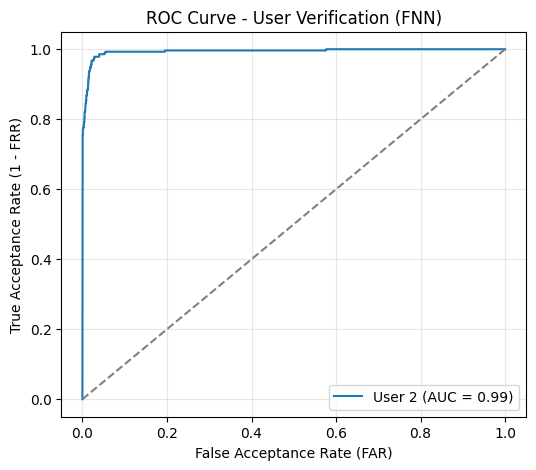

In [9]:
from sklearn.metrics import roc_curve

sample_user = 2
y_binary = (y_labels == USERS.index(sample_user)).astype(int)

scaler = StandardScaler()                                                               
X_scaled = scaler.fit_transform(X_pca)

model = build_fnn_verification()
model.fit(X_scaled, y_binary, epochs=20, batch_size=32, verbose=0)

preds = model.predict(X_scaled).ravel()
fpr, tpr, _ = roc_curve(y_binary, preds)
auc_score = roc_auc_score(y_binary, preds)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"User {sample_user} (AUC = {auc_score:.2f})")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Acceptance Rate (FAR)")
plt.ylabel("True Acceptance Rate (1 - FRR)")
plt.title("ROC Curve - User Verification (FNN)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
